In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
# Build vocab of characters
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [59]:
# Build dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [75]:
def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [105]:
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
params = [C, W1, b1, W2, b2]

In [106]:
sum(p.nelement() for p in params) # num of total params

11897

In [107]:
for p in params:
    p.requires_grad = True

In [87]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [108]:
lri = []
lossi = []
stepi = []

In [114]:
for i in range(50000):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])


    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update
    lr = 0.01
    for p in params:
        p.data += -lr * p.grad

    # STAT TRACKING
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.4787862300872803


In [ ]:
plt.plot(lri, lossi)

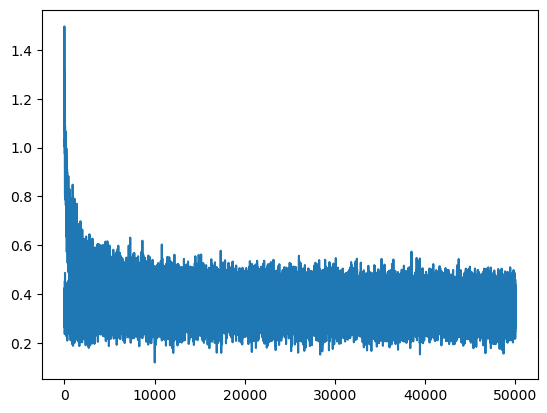

In [115]:
plt.plot(stepi, lossi)

In [116]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1711, grad_fn=<NllLossBackward0>)

In [117]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2101, grad_fn=<NllLossBackward0>)

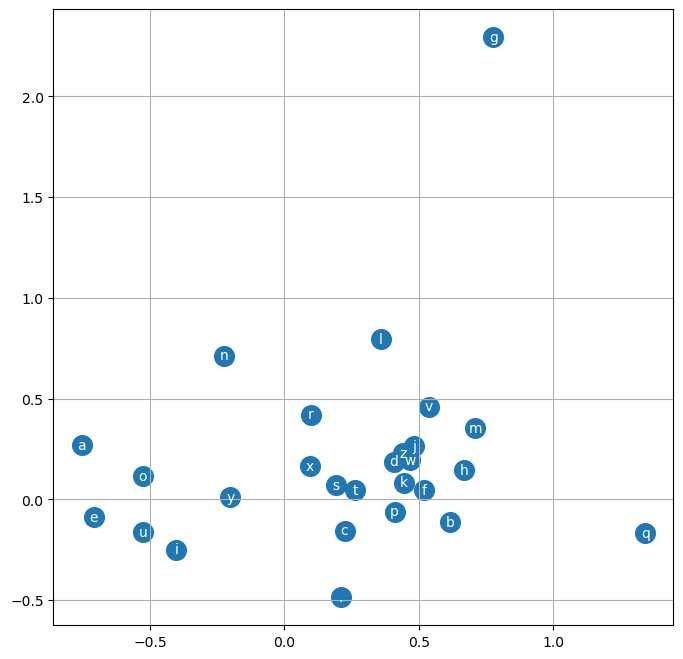

In [ ]:
# Visualization of embeddings
plt.figure(figsize = (8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s = 200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [118]:
# sampling from the model
for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

sir.
gialyn.
joca.
gylyn.
elupa.
szaymelina.
nick.
kem.
raxser.
leig.
zoussa.
ryonty.
cetre.
aylen.
nix.
keiana.
amarqua.
aabertin.
dawth.
syr.


In [ ]:
"""
EXERCISES
E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2

E02: I was not careful with the intialization of the network in this video. 
(1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? 
What loss do we achieve? (2) Can you tune the initialization to get a starting loss that is much more similar to (1)?

E03: Read the Bengio et al 2003 paper (link above), implement and try any idea from the paper. Did it work?
"""

In [125]:
# E02
g = torch.Generator().manual_seed(2147483647)

# uniform distribution
C = torch.ones((27, 10))
C /= C.sum(dim = 1, keepdim=True)

W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
params = [C, W1, b1, W2, b2]

for p in params:
    p.requires_grad = True

In [131]:
# Training with uniform dist
for i in range(50000):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])


    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update
    lr = 0.001
    for p in params:
        p.data += -lr * p.grad

    # STAT TRACKING
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.1040618419647217


In [158]:
# Train and dev loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print("Training loss: ", loss)

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print("Dev loss: ", loss)

Training loss:  tensor(9.9027, grad_fn=<NllLossBackward0>)
Dev loss:  tensor(9.9625, grad_fn=<NllLossBackward0>)


So initially, high loss is achieved, but after some training the model eventually converges to the the same/similar probability distribution.

In [159]:
# E03
# Idea to implement -> weight decay regularization. 
# Directly from paper: (by subtracting the weight decay factor times the learning rate times the value of the parameter,
# from each parameter, at each update)

# re-initialize
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
params = [C, W1, b1, W2, b2]

for p in params:
    p.requires_grad = True

In [163]:
# training loop where weight decay regularization is implemented
num_steps = 10000
weight_decay = torch.linspace(0, 1, num_steps)


for i in range(num_steps):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (32, ))
    # forward pass

    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])


    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update

    # Weight decay regularization
    lr = 0.01
    for p in params:
        p.data += -lr * (1 - weight_decay[i]) * p.grad

    # STAT TRACKING
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

print(loss.item())

2.1047887802124023


In [164]:
# Weight decay on training and dev loss
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print("Training loss: ", loss)

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
print("Dev loss: ", loss)

Training loss:  tensor(2.3407, grad_fn=<NllLossBackward0>)
Dev loss:  tensor(2.3719, grad_fn=<NllLossBackward0>)


I think the idea of weight decay regularizaton makes a lot of sense (as we approach the end of trining we want to reduce the size of the step we take), but in practice it seems that it either achieves similar or worse results from playing around with it. I suspect however with the right setup this should yield better results. In addition, this is a much more granular and precise way to adjust our learning rate over the training. 